In [1]:

import json
import random
import sys
from collections import defaultdict
import pandas as pd
import os
import math
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
sys.path.insert(0, "/home/testunot/IndoorUAV-Agent/online_eval/vla_eval")
from utils import get_glb_path
import open3d as o3d
from scipy.spatial.transform import Rotation as ScipyRot
from magnum import Vector3, Color3

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
SHARED_FOLDER = (
    "/home/testunot/IndoorUAV-Agent/online_eval/vla_eval/shared_folder"
)

DATASET_ROOT = "/home/testunot/datasets/habitat/IndoorUAV-VLA"
POSTURE_BASE = os.path.join(DATASET_ROOT, "without_screenshot")
VLA_INS_BASE = os.path.join(DATASET_ROOT, "vla_ins")

TRAJECTORIES_DIR = os.path.join(SHARED_FOLDER, "trajectories")
IMAGE_STORAGE = os.path.join(SHARED_FOLDER, "images")

# Results
EVAL_RESULTS_PATH = os.path.join(SHARED_FOLDER, "evaluation_openvla_results.json")

TEST_VLA_PATH = (
    "/home/testunot/IndoorUAV-Agent/online_eval/vla_eval/test_vla.json"
)

## Sample unsuccessfull trajecotries

In [3]:
def sample_failed_trajectories(eval_results_path, test_vla_path, n=5, seed=None):

    # Random samples n failed trajectories per difficulty

    with open(eval_results_path) as f:
        data = json.load(f)
    with open(test_vla_path) as f:
        vla_data = json.load(f)

    vla_lookup = {k.lstrip("/"): v for k, v in vla_data.items()}

    failed = defaultdict(list)
    for ep in data["per_episode_results"]:
        if not ep["success"]:
            failed[ep["difficulty"]].append(ep)

    rng = random.Random(seed)
    results = {}

    for difficulty in ["easy", "medium", "hard"]:
        pool = failed[difficulty]
        sample = rng.sample(pool, min(n, len(pool)))
        results[difficulty] = sample

    for difficulty, episodes in results.items():
        print(f"\n ---------------------------------------------------------")
        print(f" FAILED EPISODES: {difficulty.upper():<6}  ({len(episodes)} episodes)")
        for ep in episodes:
            ndtw_str = (
                f"{ep['nDTW']:.6f}" if ep["nDTW"] is not None else "N/A"
            )
            vla_info = vla_lookup.get(ep["episode"])
            action_type_str = (
                " + ".join(sorted(vla_info["action_type"]))
                if vla_info else "N/A (not found in test_vla)"
            )
            print(f"\n ---------------------------------------------------------")
            print(f"    Episode        : {ep['episode']}")
            print(f"    Action Type    : {action_type_str}")
            print(f"    Final Dist     : {ep['final_dist']:.4f} m")
            print(f"    Angle Diff     : {ep['final_angle_diff']:.4f} rad")
            print(f"    nDTW           : {ndtw_str}")

    return results

## Break down successrate by action_type:

   "action_type": [
      "turn",
      "forward"
    ]


Irrespective of order, so turn foward would accumulate to the same action_type as foward turn. Reduces the number of action_type classes and easier to analyse.

In [5]:
def breakdown_success_by_action_type(eval_results_path, test_vla_path):
    # Orders of action_types are ignored eg ["turn","forward"] == ["forward","turn"]

    print(f"\n ---------------------------------------------------------")
    with open(eval_results_path) as f:
        eval_data = json.load(f)
    with open(test_vla_path) as f:
        vla_data = json.load(f)

    # remove the leading / from test_vla.json because eval_results dosent have it
    vla_lookup = {k.lstrip("/"): v for k, v in vla_data.items()}

    DIFFICULTIES = ["easy", "medium", "hard"]

    stats = defaultdict(lambda: {
        "success": 0,
        "total": 0,
        **{f"success_{d}": 0 for d in DIFFICULTIES},
        **{f"total_{d}": 0 for d in DIFFICULTIES},
        "ndtw_vals": [],
        "dist_vals": [],
        "angle_vals": [],
    })

    unmatched = 0

    for ep in eval_data["per_episode_results"]:
        key = ep["episode"]
        if key not in vla_lookup:
            unmatched += 1
            continue

        canonical = tuple(sorted(vla_lookup[key]["action_type"]))
        d = ep["difficulty"]
        s = stats[canonical]

        s["total"] += 1
        s[f"total_{d}"] += 1

        if ep["success"]:
            s["success"] += 1
            s[f"success_{d}"] += 1

        if ep["nDTW"] is not None:
            s["ndtw_vals"].append(ep["nDTW"])
        if ep["final_dist"] is not None:
            s["dist_vals"].append(ep["final_dist"])
        if ep["final_angle_diff"] is not None:
            s["angle_vals"].append(ep["final_angle_diff"])

    if unmatched:
        print(f"⚠ {unmatched} episodes had no match in test_vla.json\n")

    def safe_rate(s, f):
        return round(s / f, 4) if f > 0 else None

    def safe_mean(vals):
        return round(sum(vals) / len(vals), 6) if vals else None

    rows = []
    for k, v in stats.items():
        rows.append({
            "action_type":           " + ".join(k),
            "total":                 v["total"],
            "total_easy":            v["total_easy"],
            "total_medium":          v["total_medium"],
            "total_hard":            v["total_hard"],
            "success_rate_overall":  safe_rate(v["success"],          v["total"]),
            "success_rate_easy":     safe_rate(v["success_easy"],     v["total_easy"]),
            "success_rate_medium":   safe_rate(v["success_medium"],   v["total_medium"]),
            "success_rate_hard":     safe_rate(v["success_hard"],     v["total_hard"]),
            "avg_nDTW":              safe_mean(v["ndtw_vals"]),
            "avg_final_dist":        safe_mean(v["dist_vals"]),
            "avg_final_angle_diff":  safe_mean(v["angle_vals"]),
        })

    df = (
        pd.DataFrame(rows)
        .sort_values("total", ascending=False)
        .reset_index(drop=True)
    )

    display(df)
    print(f"\n ---------------------------------------------------------")
    return df

In [6]:
test_df = breakdown_success_by_action_type(EVAL_RESULTS_PATH, TEST_VLA_PATH)


 ---------------------------------------------------------


,action_type,total,total_easy,total_medium,total_hard,success_rate_overall,success_rate_easy,success_rate_medium,success_rate_hard,avg_nDTW,avg_final_dist,avg_final_angle_diff
0,forward + turn,4974,0,4023,951,0.1952,NaN,0.2294,0.0505,0.004473,1.713246,1.049340
1,forward,1466,1466,0,0,0.2879,0.2879,NaN,NaN,0.015131,1.305861,0.069173
2,forward + up_down,591,0,574,17,0.1912,NaN,0.1969,0.0000,0.004745,2.600107,0.124326
3,turn,554,540,14,0,0.8971,0.9056,0.5714,NaN,0.001385,0.035956,0.325481
4,up_down,411,411,0,0,0.5620,0.5620,NaN,NaN,0.019873,2.180518,0.108839
5,forward + turn + up_down,343,0,0,343,0.0962,NaN,NaN,0.0962,0.005582,2.058649,1.128859
6,forward + right_left,156,0,130,26,0.0064,NaN,0.0077,0.0000,0.015745,2.304292,0.824542
7,turn + up_down,93,0,92,1,0.4194,NaN,0.4239,0.0000,0.013403,1.178692,0.837682
8,forward + right_left + turn,60,0,0,60,0.1000,NaN,NaN,0.1000,0.007488,2.190549,1.181995
9,right_left + turn,34,0,32,2,0.0882,NaN,0.0938,0.0000,0.011243,1.480494,0.772116



 ---------------------------------------------------------


## Function that converts a given trajectory into a visualisation 

In [8]:
def get_safe_key(episode_key: str) -> str:
    # Reproduce the safe_episode_key transform from vla__controller.py

    # handle cases where the episode key starts with / or not dpeending on test_vla or eval_results
    key = episode_key if episode_key.startswith("/") else f"/{episode_key}"

    return key.replace("/", "_").replace(":", "_").replace(" ", "_")

In [9]:
def load_trajectory_file(episode_key: str) -> dict:
    # Load trajectory
    # eg _hm3d_5_U8F9SkAsqbJ_traj_2_vla_ins_5.json.json

    # Find the saved file name from a episode key 
    safe = get_safe_key(episode_key)

    # Load the trajectory file
    trajectory = os.path.join(TRAJECTORIES_DIR, f"{safe}.json")  # find trajectory
    if os.path.exists(trajectory):
        with open(trajectory, 'r') as f:
            return json.load(f)
    else:
        raise FileNotFoundError(
            f"Trajectory not found: {trajectory} \n"
            f"Episode Key: {episode_key}"
        )
    


def load_reference_trajectory(episode_key: str) -> np.ndarray:
    """
    Loads the reference trajectory slice from posture.json using the source indices like in vla_controller.py setup_episode()

    Returns np.ndarray (N, 4) — [x, y, z, yaw_rad]
    """
    key   = episode_key.lstrip("/")
    parts = key.split("/")
    group, scene, traj, filename = parts

    # Get source indices from vla_ins
    vla_ins_path = os.path.join(VLA_INS_BASE, group, scene, traj, filename)
    with open(vla_ins_path, "r", encoding="gbk") as f:
        vla_data = json.load(f)

    source = vla_data["source"]
    start_idx = source[0] - 1
    end_idx = source[1] - 1

    # Load posture and slice using start and end index
    posture_path = os.path.join(POSTURE_BASE, group, scene, traj, "posture.json")
    with open(posture_path, "r") as f:
        posture_data = json.load(f)

    end_idx = min(end_idx, len(posture_data) - 1)
    frames  = posture_data[start_idx : end_idx + 1]

    ref = np.array(frames, dtype=float)
    ref[:, 3] = ref[:, 3] / 180.0 * np.pi

    return ref

In [10]:
def find_episode_images(episode_key: str):
    """
    Find and chronologically sort all screenshots for the same episode in images
    file name format: image_{safe_key}_{timestamp}.png
    """

    # Find the saved file name from a episode key  
    safe = get_safe_key(episode_key)

    # Ignore Timestamp
    pattern = os.path.join(IMAGE_STORAGE, f"image_{safe}_*.png")
    # Search for images with the matching episode key
    matches = glob.glob(pattern)

    if not matches:
        print(f"No matching images images found for Episode: {episode_key}")
        return None

    # Chronologically sort
    def timestamp_sort(path):
        try:
            return float(os.path.splitext(os.path.basename(path))[0].split("_")[-1])
        except ValueError:
            return None

    return sorted(matches, key=timestamp_sort)

def decode_episode_key(episode_key: str):
    # Extract (group, scene, traj) from an episode key 
    key = episode_key.lstrip("/")
    parts = key.split("/")

    if len(parts) != 4:
        raise ValueError(f"Invalid episode_key: {episode_key}. Expected 3 parts.")
    
    return parts[0], parts[1], parts[2]   # group, scene, traj

def _traj_to_habitat(points: np.ndarray) -> np.ndarray:
    """
    Convert trajectory coords [x, y, z, yaw] to Habitat world coords.
    Derived from utils.load_position / parse_transform_matrix:
        habitat.x = traj[0]
        habitat.y = traj[2] + 1.5
        habitat.z = traj[1]
    """
    hab = np.zeros((len(points), 3))
    hab[:, 0] = -points[:, 0]          # Flip X
    hab[:, 1] = points[:, 2]           # Z becomes Up (Y)
    hab[:, 2] = -points[:, 1]          # Flip the forward axis
    return hab

def _color_sensor_key(obs: dict):
    for key in obs:
        arr = obs[key]
        if isinstance(arr, np.ndarray) and arr.ndim == 3 and arr.shape[2] in (3, 4):
            return key
    return None

def _traj_to_habitat(points: np.ndarray) -> np.ndarray:
    """
    Convert trajectory coords applying the axis flips to account 
    for Habitat's -Z forward and the np.pi camera rotation.
    """
    hab = np.zeros((len(points), 3))
    hab[:, 0] = points[:, 0]          # Flip X
    hab[:, 1] = points[:, 2]           # Z becomes Up (Y)
    hab[:, 2] = points[:, 1]          # Flip the forward axis
    return hab


### Convert to video

In [11]:

def stitch_trajectory_video(
    episode_key: str,
    output_path: str = None
) -> str:
    """
    Stitches all rendered frames for an episode into an mp4

    episode_key: eg "hm3d_5/U8F9SkAsqbJ/traj_2/vla_ins_5.json" leading / does not matter
    """
    images = find_episode_images(episode_key)
    if images is None:
        raise RuntimeError("Error episode images can not be found retrieved!!")

    traj_data = load_trajectory_file(episode_key)

    # ?
    status = "SUCCESS" if traj_data["success"] else "FAILED"

    safe = get_safe_key(episode_key)

    if output_path is None:
        video_dir = os.path.join(SHARED_FOLDER, "videos")
        os.makedirs(video_dir, exist_ok=True)
        output_path = os.path.join(video_dir, f"{safe}.mp4")

    # sample image dimensions
    first = cv2.imread(images[0])
    h, w = first.shape[:2]

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        1, # make fps 1. there are maximum 12 images per episode
        (w, h),
    )

    total = len(images)
    for i, img_path in enumerate(images):
        frame = cv2.imread(img_path)
        if frame is None:
            print(f"Skipping unreadable: {img_path}")
            continue

        # Step counter
        cv2.putText(frame, f"Step {i}/{total - 1}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        # Status badge
        color = (0, 200, 0) if traj_data["success"] else (0, 0, 220)
        cv2.putText(frame, status, (10, 62),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        writer.write(frame)

    writer.release()
    print(f"Video saved to {output_path}")
    return output_path

### Convert to 3d Trajectory

In [31]:
def plot_trajectory_3d(
    episode_key: str
) -> dict:

    traj_data  = load_trajectory_file(episode_key)
    points_raw = np.array(traj_data["trajectory"])
    ref_raw    = load_reference_trajectory(episode_key)

    n = len(points_raw)
    xs, ys, zs = points_raw[:, 0], points_raw[:, 1], points_raw[:, 2]
    rxs, rys, rzs = ref_raw[:, 0], ref_raw[:, 1], ref_raw[:, 2]

    fig = plt.figure(figsize=(18, 6))

    views = [
        ("Top-Down (XY)", 90, 270),
        ("Side View (XZ)", 0, 270),
        ("Front View (YZ)", 0, 0)
    ]

    seg_pts  = np.stack([xs, ys, zs], axis=1)
    segments = [seg_pts[i : i + 2] for i in range(n - 1)]

    for i, (v_title, v_elev, v_azim) in enumerate(views):
        ax = fig.add_subplot(1, 3, i + 1, projection="3d")
        ax.view_init(elev=v_elev, azim=v_azim)

        # Reference trajectory (dashed cyan)
        ax.plot(rxs, rys, rzs,
                color="cyan", linewidth=1.5, linestyle="--",
                zorder=1, label="Reference", alpha=0.8)
        ax.scatter(rxs, rys, rzs,
                   color="cyan", s=20, zorder=2, depthshade=False, alpha=0.6)

        # Reference start / end
        ax.scatter(*ref_raw[0, :3],  color="cyan", s=120, marker="^",
                   zorder=5, depthshade=False, label="Ref Start")
        ax.scatter(*ref_raw[-1, :3], color="cyan", s=120, marker="X",
                   zorder=5, depthshade=False, label="Ref End")

        # Predicted trajectory (plasma gradient)
        lc = Line3DCollection(
            segments,
            cmap="plasma",
            norm=plt.Normalize(0, n - 1),
            linewidth=2,
            zorder=3,
        )
        lc.set_array(np.arange(n - 1))
        ax.add_collection3d(lc)
        
        ax.scatter(xs, ys, zs, c=np.arange(n), cmap="plasma",
                   s=30, zorder=4, depthshade=False)

        # Predicted start / end
        ax.scatter(*points_raw[0, :3],  color="lime", s=140, marker="^",
                   zorder=6, depthshade=False, label="Pred Start")
        ax.scatter(*points_raw[-1, :3], color="red",  s=140, marker="X",
                   zorder=6, depthshade=False, label="Pred End")

        # Local labels and title
        ax.set_title(v_title, fontsize=10)
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        ax.set_zlabel("Z (m)")
        if i == 0: ax.legend(fontsize=8)

    # Global Title + Formatting
    status = "SUCCESS" if traj_data["success"] else "FAILED"
    fig.suptitle(f"{episode_key}\n{status} | Steps: {traj_data['steps']}", fontsize=11)
    
    # Add one shared colorbar at the end
    cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
    fig.colorbar(lc, cax=cbar_ax, label="Predicted Step")

    fig.subplots_adjust(left=0.05, right=0.88, bottom=0.1, top=0.85, wspace=0.2)
    print("Saved")
    plt.savefig("/home/testunot/Downloads/output.png",dpi=300, bbox_inches='tight')
    plt.show()

    return traj_data

### Print instruction

In [22]:

def print_vla_instruction(episode_key: str):
    key = episode_key.lstrip("/")
    json_path = os.path.join(VLA_INS_BASE, key)

    with open(json_path, "r") as f:
        data = json.load(f)

    print(f"Episode: {episode_key}")
    print(f"Instruction: {data['instruction']}")
    print(f"Source: {data['source']}")

In [57]:
# Test
results = sample_failed_trajectories(EVAL_RESULTS_PATH, TEST_VLA_PATH, n=5)


 ---------------------------------------------------------
 FAILED EPISODES: EASY    (5 episodes)

 ---------------------------------------------------------
    Episode        : hm3d_12/wPLokgvCnuk/traj_2/vla_ins_9.json
    Action Type    : up_down
    Final Dist     : 7.4966 m
    Angle Diff     : 0.2113 rad
    nDTW           : 0.000000

 ---------------------------------------------------------
    Episode        : hm3d_9/PuFu1zFVc4k/traj_-1/vla_ins_7.json
    Action Type    : forward
    Final Dist     : 1.3172 m
    Angle Diff     : 0.0938 rad
    nDTW           : 0.004720

 ---------------------------------------------------------
    Episode        : hm3d_5/U8F9SkAsqbJ/traj_2/vla_ins_6.json
    Action Type    : forward
    Final Dist     : 1.6609 m
    Angle Diff     : 0.0511 rad
    nDTW           : 0.000137

 ---------------------------------------------------------
    Episode        : hm3d_17/xvDx98avcwd/traj_-2/vla_ins_9.json
    Action Type    : turn
    Final Dist     :

Video saved to /home/testunot/IndoorUAV-Agent/online_eval/vla_eval/shared_folder/videos/_mp3d_2_pa4otMbVnkk_traj_-4_vla_ins_2.json.mp4
Saved


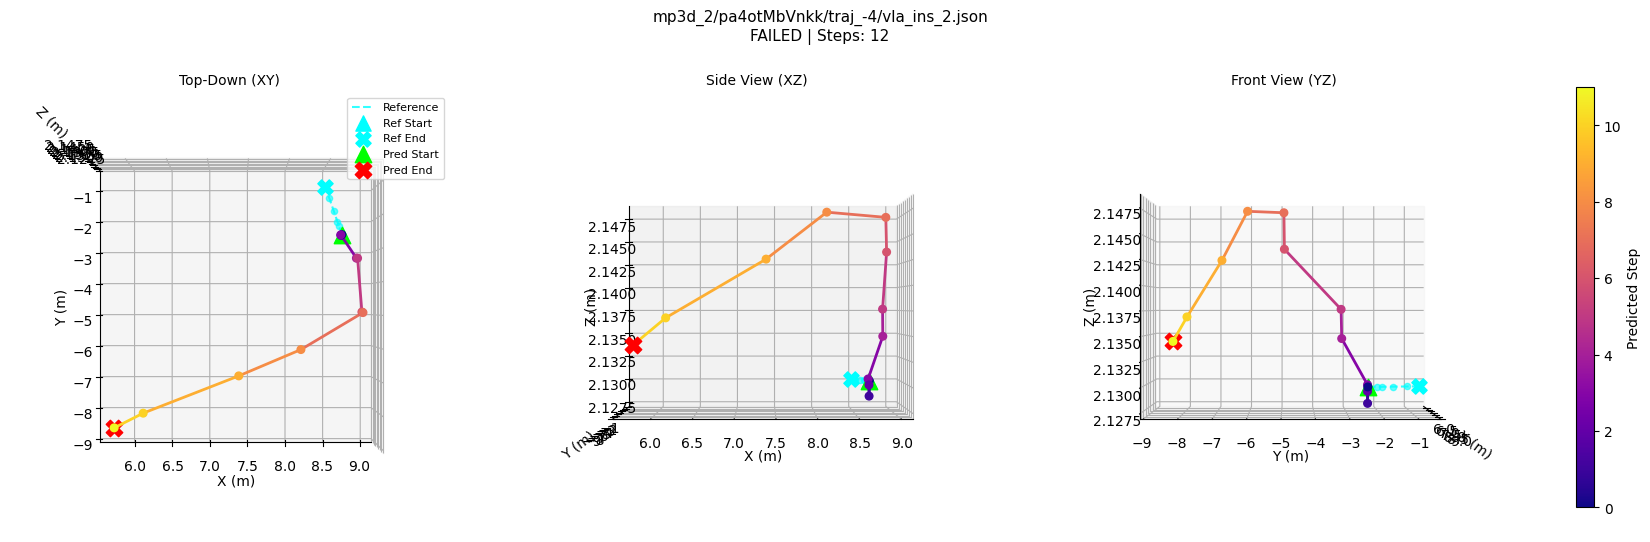

Episode: mp3d_2/pa4otMbVnkk/traj_-4/vla_ins_2.json
Instruction: Turn left toward the painting, move forward past the window, then turn right into the hallway.
Source: [50, 87]


In [59]:
TEST_TRAJ = "mp3d_2/pa4otMbVnkk/traj_-4/vla_ins_2.json"

stitch_trajectory_video(TEST_TRAJ)
plot_trajectory_3d(TEST_TRAJ)
print_vla_instruction(TEST_TRAJ)